In [214]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import folium
import plotly.express as px
import math


In [215]:
lfpl_df = pd.read_csv("Louisville_Metro_KY_-_Library_Collection_Inventory.csv")
zip_df = pd.read_csv("Louisville_KY_Free_Public_Libraries (1).csv")

In [216]:
lfpl_df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


In [217]:
lfpl_df['ItemLocation'].unique()

array(['Main', 'South Central', 'Southwest', 'Remote Shelving - Main',
       'Iroquois', 'Newburg', 'Shively', 'Bon Air', 'St Matthews',
       'Northeast', 'Fairdale', 'Middletown', 'Jeffersontown', 'Shawnee',
       'Highlands - Shelby Park', 'Crescent Hill', 'Portland', 'Western',
       'Remote Shelving - Shawnee', 'Childrens Main Library', 'Main Teen',
       'Childrens Bookmobile', 'Adult Bookmobile', 'Content Management'],
      dtype=object)

In [218]:
zip_df['LFPL_NAME'].unique()

array(['BON AIR', 'FAIRDALE', 'IROQUOIS', 'CRESCENT HILL',
       'JEFFERSONTOWN', 'HIGHLANDS-SHELBY PARK', 'MIDDLETOWN',
       'ST. MATTHEWS', 'SOUTH CENTRAL REGIONAL', 'PORTLAND', 'SHIVELY',
       'SHAWNEE', 'MAIN', 'NEWBURG', 'PARKLAND', 'NORTHEAST REGIONAL',
       'WESTERN', 'SOUTHWEST REGIONAL', 'FERN CREEK'], dtype=object)

In [219]:
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Main','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('South Central','SOUTH CENTRAL REGIONAL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Southwest','SOUTHWEST REGIONAL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Iroquois','IROQUOIS')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Newburg','NEWBURG')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Shively','SHIVELY')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Bon Air','BON AIR')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('St Matthews','ST. MATTHEWS')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Northeast','NORTHEAST REGIONAL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Fairdale','FAIRDALE')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Middletown','MIDDLETOWN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Jeffersontown','JEFFERSONTOWN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Shawnee','SHAWNEE')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Highlands - Shelby Park','HIGHLANDS-SHELBY PARK')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Crescent Hill','CRESCENT HILL')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Portland','PORTLAND')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Western','WESTERN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Remote Shelving - Shawnee','SHAWNEE')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Childrens Main Library','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Main Teen','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Content Management','MAIN')
lfpl_df['ItemLocation'] = lfpl_df['ItemLocation'].replace('Remote Shelving - Main','MAIN')


In [220]:
lfpl_df['ItemLocation'].unique()

array(['MAIN', 'SOUTH CENTRAL REGIONAL', 'SOUTHWEST REGIONAL', 'IROQUOIS',
       'NEWBURG', 'SHIVELY', 'BON AIR', 'ST. MATTHEWS',
       'NORTHEAST REGIONAL', 'FAIRDALE', 'MIDDLETOWN', 'JEFFERSONTOWN',
       'SHAWNEE', 'HIGHLANDS-SHELBY PARK', 'CRESCENT HILL', 'PORTLAND',
       'WESTERN', 'Childrens Bookmobile', 'Adult Bookmobile'],
      dtype=object)

In [221]:
lfpl_df['Name_lower'] = lfpl_df['ItemLocation'].str.lower()
zip_df['Name_lower'] = zip_df['LFPL_NAME'].str.lower()

In [222]:
merged = pd.merge(
    lfpl_df, zip_df[['Name_lower', 'ZIP']],
    on = 'Name_lower', how = 'left'
)

merged.drop(columns=['Name_lower'], inplace=True)
merged.to_csv('merged_2.csv', index = False)

In [223]:
merged_df = pd.read_csv("merged_2.csv")
census_df = pd.read_csv("Census_by_County.csv")

In [224]:
merged_df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203.0
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219.0
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272.0
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219.0
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272.0


In [225]:
census_df.head()

,ZIP Code,Town,State Abbreviation,State,Metro,Primary County,Total population,Median Household Income,Male,Female,...,Not Hispanic or Latino - White alone.1,Not Hispanic or Latino - Black or African American alone.1,Not Hispanic or Latino - American Indian and Alaska Native alone.1,Not Hispanic or Latino - Asian alone.1,Not Hispanic or Latino - Native Hawaiian and Other Pacific Islander alone.1,Not Hispanic or Latino - Some Other Race alone.1,Not Hispanic or Latino - Two or More Races.1,"Citizen, 18 and over population - Male.1","Citizen, 18 and over population - Female.1",Total housing units
0,40023,Fisherville,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,"6,484","$135,863","3,395","3,089",...,84.1,7.1,0.0,3.1,0.0,0.3,0.9,49.2,50.8,"2,377"
1,40025,Glenview,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,652,NaN,327,325,...,75.6,0.0,0.0,3.7,0.0,0.0,4.3,55.9,44.1,259
2,40041,Masonic Home,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,518,NaN,153,365,...,91.3,6.9,1.5,0.0,0.0,0.0,0.2,29.5,70.5,291
3,40059,Prospect,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,"19,899","$165,000","9,878","10,021",...,86.4,4.0,0.0,4.3,0.0,0.1,2.8,48.8,51.2,"8,400"
4,40118,Fairdale,KY,Kentucky,"Louisville/Jefferson County, KY-IN",Jefferson County,"9,903","$52,257","5,214","4,689",...,76.3,2.0,0.0,0.0,0.0,0.0,2.2,50.4,49.6,"4,405"


In [226]:
title_counts = merged_df['Title'].value_counts().reset_index()
title_counts.columns = ['Title', 'title_count']
title_counts

,Title,title_count
0,The courier-journal,1352
1,The Blood-horse.,1028
2,People weekly.,909
3,Annual report.,588
4,Consumer reports.,498
...,...,...
601960,Jeeves and the wedding bells : an homage to P....,1
601961,Sandrine's Case,1
601962,Ghostgirl : lovesick,1
601963,Daughters of the sea : Hannah,1


In [227]:
merged_df["ZIP"] = pd.to_numeric(merged_df["ZIP"], errors="coerce").astype("Int64")
census_df["ZIP Code"] = pd.to_numeric(census_df["ZIP Code"], errors="coerce").astype("Int64")

In [228]:
merged_df = merged_df.merge(
    census_df[['ZIP Code', 'Total population']],
    how = 'left',
    left_on='ZIP',
    right_on='ZIP Code'
)

merged_df.drop(columns='ZIP Code', inplace=True)

In [229]:
merged_df['ZIP'] = pd.to_numeric(merged_df['ZIP'], errors='coerce').fillna(0).astype(int)
merged_df

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP,Total population
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203,"17,540"
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219,"39,107"
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272,"37,595"
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219,"39,107"
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272,"37,595"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657550,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,MAIN,10.02,2022/07/01 04:00:00+00,1657551,40203,"17,540"
1657551,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,NEWBURG,10.02,2022/07/01 04:00:00+00,1657552,40218,"33,292"
1657552,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,SOUTH CENTRAL REGIONAL,10.02,2022/07/01 04:00:00+00,1657553,40219,"39,107"
1657553,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,WESTERN,10.02,2022/07/01 04:00:00+00,1657554,40203,"17,540"


In [230]:
merged_df

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP,Total population
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203,"17,540"
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219,"39,107"
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272,"37,595"
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219,"39,107"
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272,"37,595"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657550,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,MAIN,10.02,2022/07/01 04:00:00+00,1657551,40203,"17,540"
1657551,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,NEWBURG,10.02,2022/07/01 04:00:00+00,1657552,40218,"33,292"
1657552,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,SOUTH CENTRAL REGIONAL,10.02,2022/07/01 04:00:00+00,1657553,40219,"39,107"
1657553,2527332,The afrominimalist's guide to living with less,"Platt, Christine",9.781982e+12,2022,Book,Adult Non-Fiction,WESTERN,10.02,2022/07/01 04:00:00+00,1657554,40203,"17,540"


In [231]:
books_per_pop = (
    merged_df.groupby("ItemLocation", as_index=False)
        .agg(
        Title_count = ("Title", "count"),
        Total_population=("Total population","first")
        )
)

In [232]:
books_per_pop['Total_population'] = books_per_pop['Total_population'].replace(',', '', regex=True)

In [233]:
books_per_pop['Total_population'] = books_per_pop['Total_population'].fillna(0)

In [234]:
books_per_pop['Total_population'] = (
    pd.to_numeric(books_per_pop['Total_population'], errors='coerce') 
      .fillna(0)                                           
      .astype(np.int64)
)   

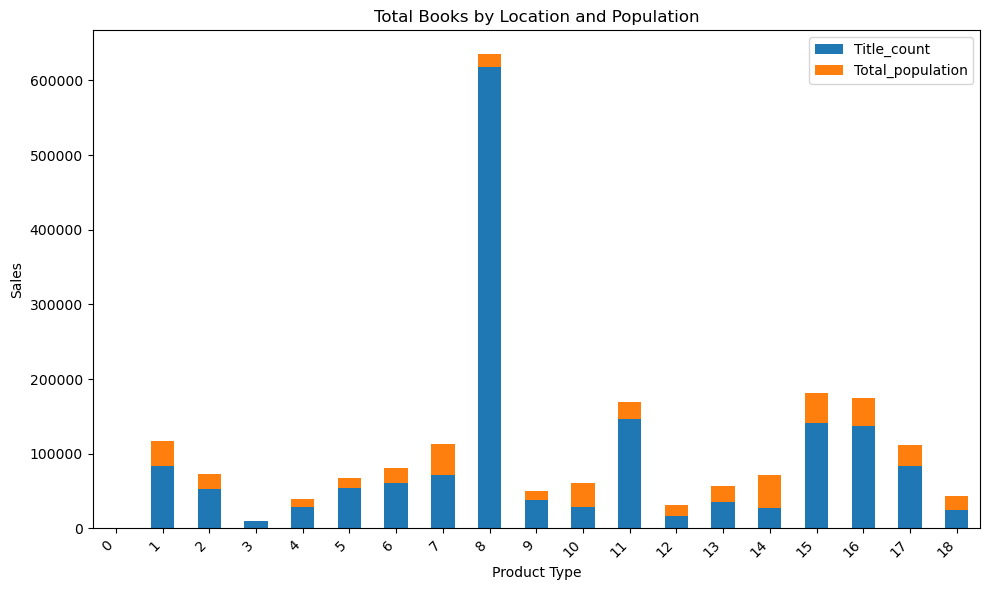

In [235]:
books_per_pop.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Total Books by Location and Population')
plt.xlabel('Product Type')
plt.ylabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [236]:
merged_df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId,ZIP,Total population
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,MAIN,25.95,2022/07/01 04:00:00+00,1,40203,"17,540"
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,2,40219,"39,107"
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,3,40272,"37,595"
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,SOUTH CENTRAL REGIONAL,20.00,2022/07/01 04:00:00+00,4,40219,"39,107"
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,SOUTHWEST REGIONAL,19.99,2022/07/01 04:00:00+00,5,40272,"37,595"


In [237]:
merged_df["Total population"] = pd.to_numeric(merged_df["Total population"], errors="coerce")
merged_df["Total population"] = merged_df["Total population"].fillna(0).astype(int)

In [238]:
merged_df.dtypes

BibNum                int64
Title                object
Author               object
ISBN                float64
PublicationYear       int64
ItemType             object
ItemCollection       object
ItemLocation         object
ItemPrice           float64
ReportDate           object
ObjectId              int64
ZIP                   int32
Total population      int32
dtype: object

In [239]:
zip_df.dtypes

X             float64
Y             float64
OBJECTID        int64
LFPL_NAME      object
LFPL_ADD       object
LFPL_LOC       object
LFPL_WEB       object
TELEPHONE      object
LATITUDE      float64
LONGITUDE     float64
ZIP             int64
Name_lower     object
dtype: object

In [240]:
map_df = pd.merge(merged_df,zip_df, on="ZIP",how='inner')


In [241]:
agg_df = (
    map_df.groupby(["ItemLocation", "LATITUDE", "LONGITUDE"])
    .size()
    .reset_index(name="title_count")
)


In [242]:
m = folium.Map(location=[38.25, -85.75], zoom_start=11, tiles="cartodb positron")

In [243]:
for _, row in agg_df.iterrows():
    radius = np.log(row["title_count"] + 1) * 1 
    popup_text = f"<b>{row['ItemLocation']}</b><br>Titles: {row['title_count']}"
    
    folium.CircleMarker(
        location=[row["LATITUDE"], row["LONGITUDE"]],
        radius=radius,
        color="#3186cc",
        fill=False,
        fill_color="#3186cc",
        fill_opacity=0.9,
        popup=folium.Popup(popup_text, max_width=250)
    ).add_to(m)


In [244]:
m.save("jefferson_bubble_map.html")